In [2]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt

# This
from numerics import *
from seismic import *

In [41]:
class GMMLT:
    def __init__(self, gmms:list, T:float, weights:jax.typing.ArrayLike):
        self.T = T
        self.gmms = gmms
        self.weights = weights

    # Calculate for a single GMM. Takes R so we don't repeat the calculation every time.
    def calc_single(self, i:int, Mw:float, site:Site, fault:Fault, R:jax.Array):
        return lax.switch(i, self.gmms, Mw, self.T, site, fault, R)

    def tree_flatten(self):
        return (self.T, self.weights), self.gmms
    
    @classmethod
    def tree_unflatten(cls, aux, children):
        return cls(aux, *children)

gmms = [f_ASK14, f_BSSA14, f_CB14, f_CY14, f_Idriss14]
#gmms = gmms + [f_epistemic_AAY14(gmm, -1.645) for gmm in gmms] + [f_epistemic_AAY14(gmm, 1.645) for gmm in gmms]
gmmlt = GMMLT(gmms, .5, jnp.ones(len(gmms)) / len(gmms))
gmm_idcs = jnp.arange(len(gmms))

lnR = jnp.linspace(0.1, 4, 7)
M = jnp.linspace(3.5, 8, 7)
MlnR = jnp.stack(jnp.meshgrid(lnR, M), axis = -1).reshape(7**2, 2)
M, lnR = MlnR.T
x = jnp.exp(lnR)
y = 0

faults = jax.vmap(Fault, in_axes = (0, None, None, None, None, None, None, None, None, None))(x, y, 5.3, 0.1, 30, 45, 20, 1.2, 0., MFD(2, 1))

vmap_gmms = jax.vmap(gmmlt.calc_single, in_axes = (0, None, None, None, None))
vmap_MlnR = jax.vmap(vmap_gmms, in_axes = (None, 0, None, 0, 0))
site = Site(0, 0, 760, 1.2, 3.5, 0.)
gmm_out, _ = vmap_MlnR(gmm_idcs, M, site, faults, jax.vmap(calc_R, in_axes = (None, 0))(site, faults))

In [42]:
# Lacour kernel
CL = C_Lacour(MlnR)

def C_Paciorek(x_all:jax.Array, y_all:jax.Array):
    """
    Compute the nonstationary covariance matrix using the kernel from Paciorek & Schervish (2003) [DOI:10.5555/2981345.2981380].

    Parameters
    ----------
    x_all : jax.Array
        Array of input locations (N, D).
    y_all : jax.Array
        Array of values at input locations (N, D).

    Returns
    -------
    jax.Array
        Covariance matrix of shape (N, N).
    """
    # Dimension
    n,d = y_all.shape
    # Standard deviation
    std = y_all.std(axis = -1, ddof = 1)
    # Crossvariance
    crossvar = std[None] * std[:, None]
    # Covariogram
    covarg = jnpla.norm(y_all[None] - y_all[:, None], axis = -1) / d

    # Lengthscale + adaptive kernel from Paciorek + Schervish
    lscale = 1 / (std + 1e-4) ** (1 / 3)
    lscale = lscale * (std.min() + 1e-4) ** (1 / 3) * covarg.mean()
    lscale_prod = lscale[None] * lscale[:, None]
    lscale_sqsum = lscale[None]**2 + lscale[:, None]**2
    C = crossvar * ((2 * lscale_prod) / lscale_sqsum) ** (1 / 2) * jnp.exp(-covarg**2 / lscale_sqsum)
    return C

# Paciorek kernel
CP = C_Paciorek(MlnR, gmm_out)

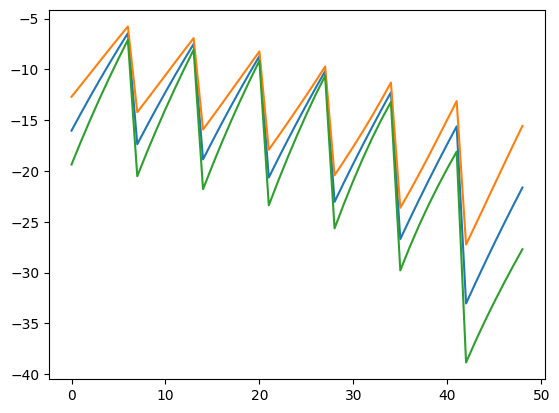

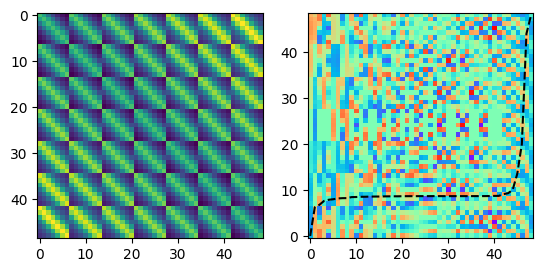

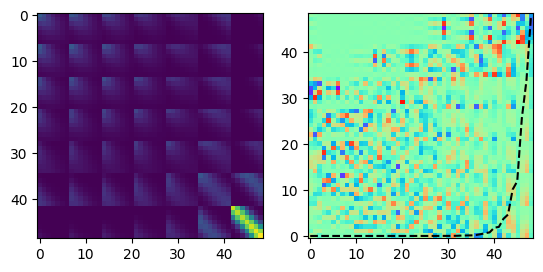

In [47]:
plt.plot(gmm_out.mean(axis = -1))
plt.plot(gmm_out.mean(axis = -1) + gmm_out.std(axis = -1))
plt.plot(gmm_out.mean(axis = -1) - gmm_out.std(axis = -1))
for C in [CL, CP]:
    eigvals, eigvecs = jnpla.eigh(C)
    fig,ax = plt.subplots(1, 2)
    ax[0].imshow(C)
    ax[1].imshow(eigvecs, cmap = 'rainbow', origin = 'lower')
    ax[1].plot((eigvals - eigvals.min()) / (eigvals.max() - eigvals.min()) * (eigvals.shape[0]-1), c = 'k', ls = '--')
    plt.show()

In [2]:
site = Site(0., 0., 760., 0.5, 2.9, 1.)
mfd1 = MFD(4., .8, 4., 8.)
mfd2 = MFD(4., 1., 4., 8.)
mfd3 = MFD(5., 1.2, 4., 5.)
fault1 = Fault(0., 20., 3.0, 0.1, 40., 80., 90., 2.5, 0., mfd1)
fault2 = Fault(0., 25., 0.5, 0.2, 80., 80., 30., 0.5, 1., mfd2)
fault3 = Fault(22., 12.1, 3.9, 1.2, 130., 40., 22., 3., 1., mfd3)
faults = [fault1, fault2, fault3]
fault_tree = make_fault_tree(faults)
fault_tree1 = make_fault_tree([faults[0]])
fault_tree2 = make_fault_tree([faults[1]])

scn = Scenario(site, fault_tree)
scn1 = Scenario(site, fault_tree1)
scn2 = Scenario(site, fault_tree2)

In [43]:
class GMMLT:
    def __init__(self, gmms:list, T:float, weights:jax.typing.ArrayLike):
        self.T = T
        self.gmms = gmms
        self.weights = weights

    # Calculate for a single GMM. Takes R so we don't repeat the calculation every time.
    def calc_single(self, i:int, Mw:float, site:Site, fault:Fault, R:jax.Array):
        return lax.switch(i, self.gmms, Mw, self.T, site, fault, R)

    def tree_flatten(self):
        return (self.T, self.weights), self.gmms
    
    @classmethod
    def tree_unflatten(cls, aux, children):
        return cls(aux, *children)

gmms = [f_ASK14, f_BSSA14, f_CB14, f_CY14, f_Idriss14]
gmms = gmms + [f_epistemic_AAY14(gmm, -1.645) for gmm in gmms] + [f_epistemic_AAY14(gmm, 1.645) for gmm in gmms]
gmmlt = GMMLT(gmms, -1., jnp.ones(len(gmms)) / len(gmms))
gmm_idcs = jnp.arange(len(gmms))

M = jnp.linspace(3, 8, 5)
lnR = jnp.linspace(0.1, 4, 5)
vs30 = jnp.array([150, 260, 760, 1080, 1500])
dip = jnp.array([0, 22.5, 45, 67.5, 90])
z_tor = jnp.array([0.1, 0.5, 1., 2., 4.])
z_hyp = jnp.array([1., 2., 3., 5., 7.5, ])

M, lnR, vs30, dip, z_tor, z_hyp = jnp.stack(jnp.meshgrid(M, lnR, vs30, dip, z_tor, z_hyp), axis = 0).reshape(6, 5 **6)
x = jnp.exp(lnR)
y = 0.
sites = jax.vmap(Site, in_axes = (None, None, 0, None, None, None))(0., 0., vs30, 0.8, 2.3, 0.)
faults = jax.vmap(Fault, in_axes = (0, None, 0, 0, None, None, None, None, None, None))(x, 0., z_hyp, z_tor, 30, 45, 45, 1.2, 0., MFD(2, 1))

gmm_idx_vmap = jax.vmap(gmmlt.calc_single, in_axes = (0, None, None, None, None))
gmm_out, _ = jax.vmap(gmm_idx_vmap, in_axes = (None, 0, 0, 0, 0))(gmm_idcs, M, sites, faults, jax.vmap(calc_R, in_axes = (0, 0))(sites, faults))

In [49]:
gmm_mu = gmm_out.mean(axis = -1)
gmm_std = gmm_out.std(axis = -1)